# Housing Price Prediction

In [1]:
import pandas as pd 
import numpy as np
import seaborn as sns
import  matplotlib.pyplot as plt

In [2]:
# load data

df = pd.read_csv('house_prices_dataset.csv')
df.head()

,square_feet,num_rooms,age,distance_to_city(km),price
0,2248.357077,3,92,22.997972,200374.090410
1,1930.867849,2,22,13.984254,268784.847337
2,2323.844269,6,33,21.500945,315020.857676
3,2761.514928,3,63,10.343638,355111.468459
4,1882.923313,7,54,25.485200,234197.123903


In [3]:
# Basic inpections
print("Basic inspection results")
print(f"Shape : {df.shape}")
print(f"Columns: {list(df.columns)}")

print("First 5 rows")
print(df.head())

print("\nSummary statistic")
print(df.describe().round(2))

Basic inspection results
Shape : (10000, 5)
Columns: ['square_feet', 'num_rooms', 'age', 'distance_to_city(km)', 'price']
First 5 rows
   square_feet  num_rooms  age  distance_to_city(km)          price
0  2248.357077          3   92             22.997972  200374.090410
1  1930.867849          2   22             13.984254  268784.847337
2  2323.844269          6   33             21.500945  315020.857676
3  2761.514928          3   63             10.343638  355111.468459
4  1882.923313          7   54             25.485200  234197.123903

Summary statistic
       square_feet  num_rooms       age  distance_to_city(km)      price
count     10000.00   10000.00  10000.00              10000.00   10000.00
mean       1999.15       4.50     49.52                 15.36  263011.57
std         501.02       1.71     28.99                  8.33   98336.95
min         500.00       2.00      0.00                  1.00  -95613.14
25%        1663.70       3.00     24.00                  8.12  196791.51


In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 5 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   square_feet           10000 non-null  float64
 1   num_rooms             10000 non-null  int64  
 2   age                   10000 non-null  int64  
 3   distance_to_city(km)  10000 non-null  float64
 4   price                 10000 non-null  float64
dtypes: float64(3), int64(2)
memory usage: 390.8 KB


In [4]:
# Missing Values
print("Missing Values")
missing = df.isnull().sum()
missing_pct = (df.isnull().mean() * 100).round(2)

missing_df = pd.DataFrame({
    'count':missing,
    'percentage':missing_pct
})
print(missing_df[missing_df['count'] > 0].sort_values('percentage', ascending=False))

Missing Values
Empty DataFrame
Columns: [count, percentage]
Index: []


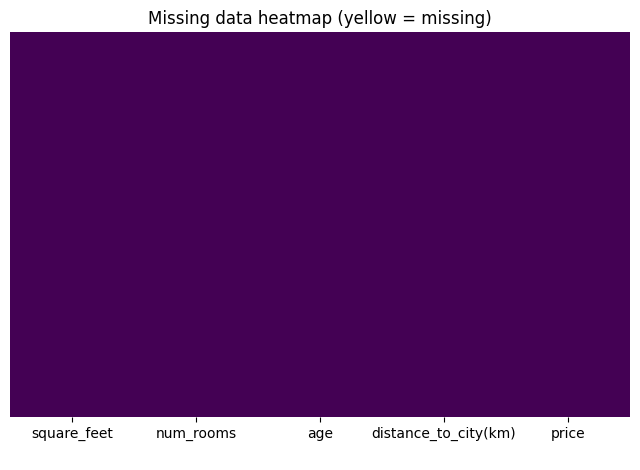

In [5]:
# plot missing data
import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis',yticklabels=False)
plt.title("Missing data heatmap (yellow = missing)")
plt.xlabel(" ")
plt.ylabel("")
plt.show()

In [6]:
# 4. Target Distribution
TARGET = "price"
print("Target Distribution")
print(df[TARGET].describe())

Target Distribution
count     10000.000000
mean     263011.571609
std       98336.945117
min      -95613.138249
25%      196791.510684
50%      262497.361236
75%      330445.581908
max      660168.255648
Name: price, dtype: float64


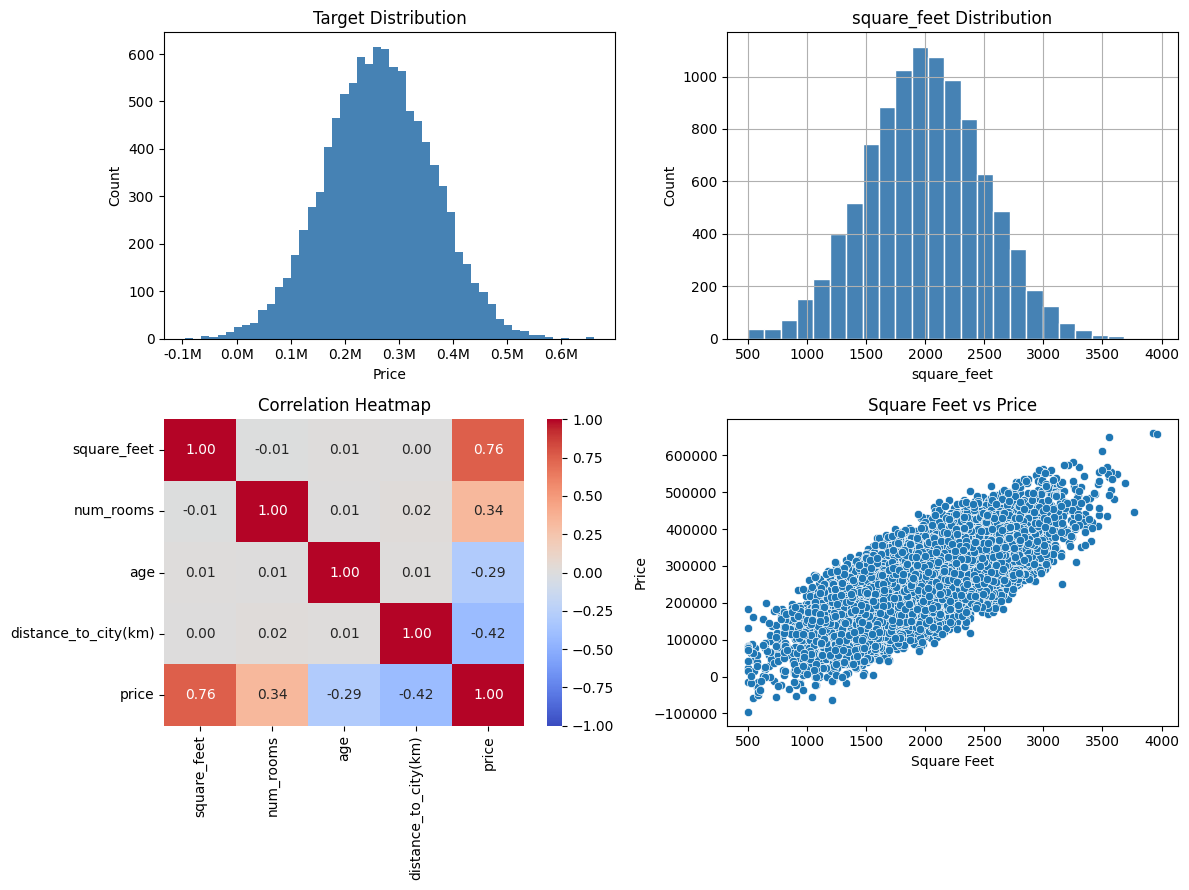

In [24]:
import matplotlib.ticker as mtick

fig, axes = plt.subplots(2,2, figsize=(12,9))

# 1. target distribution
df[TARGET].plot(kind='hist', bins=50, ax=axes[0,0], color='steelblue')
# sns.histplot(df[TARGET], kde=True, ax=axes[0,0])
axes[0,0].set_title("Target Distribution")
axes[0,0].set_xlabel("Price")
axes[0,0].set_ylabel("Count")
# axes[0,0].tick_params(axis='x', rotation=45)
axes[0,0].xaxis.set_major_formatter(
    mtick.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M")
)

# 2. feature distribution
df['square_feet'].hist(ax=axes[0,1], bins=25, color='steelblue', edgecolor='white')
axes[0,1].set_title("square_feet Distribution")
axes[0,1].set_xlabel("square_feet")
axes[0,1].set_ylabel("Count")

# 3. correlation heatmap
num_cols = df.select_dtypes(include=np.number).columns
sns.heatmap(df[num_cols].corr(), annot=True, fmt='.2f',
            cmap='coolwarm', vmin=-1, vmax=1, ax=axes[1,0])
axes[1,0].set_title("Correlation Heatmap")

# 4. feature vs target
sns.scatterplot(x=df['square_feet'], y=df[TARGET], ax=axes[1,1])
axes[1,1].set_title("Square Feet vs Price")
axes[1,1].set_xlabel("Square Feet")
axes[1,1].set_ylabel("Price")

plt.tight_layout()
plt.show()

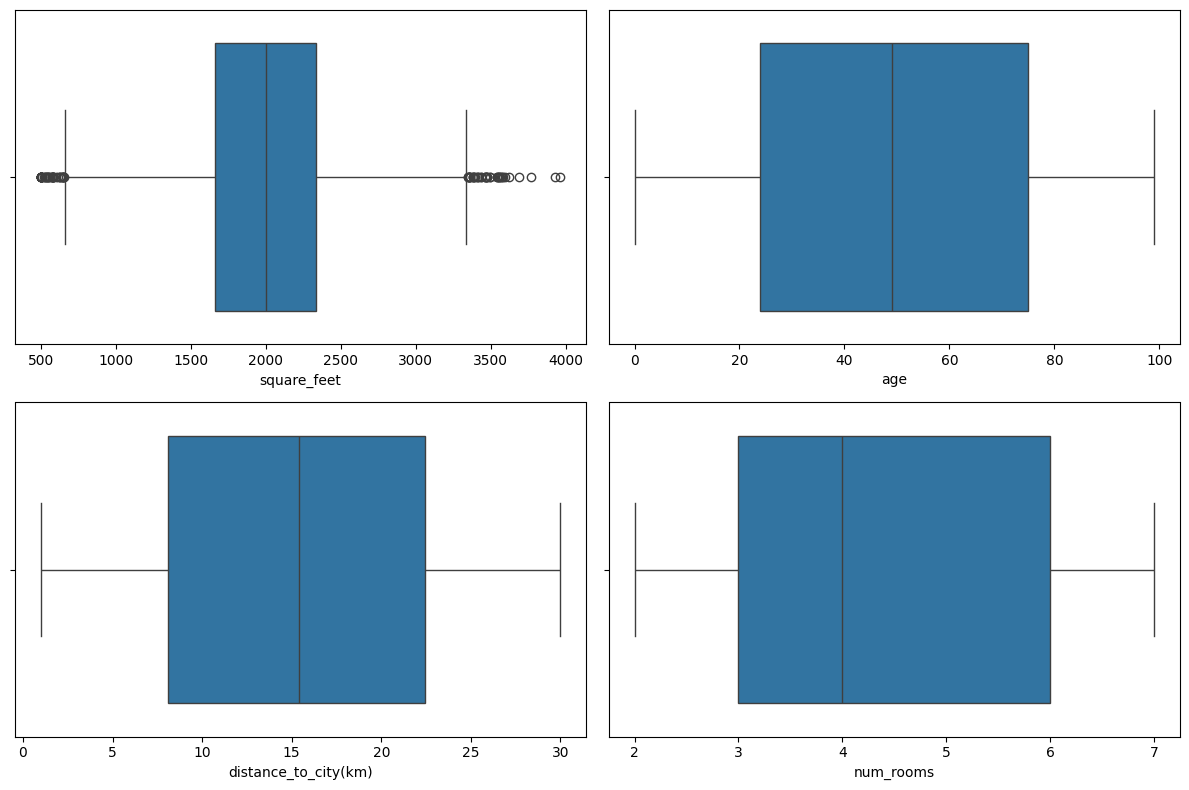

In [26]:
fig, axes = plt.subplots(2,2, figsize=(12,8))

sns.boxplot(x=df['square_feet'], ax=axes[0,0])
sns.boxplot(x=df['age'], ax=axes[0,1])
sns.boxplot(x=df['distance_to_city(km)'], ax=axes[1,0])
sns.boxplot(x=df['num_rooms'], ax=axes[1,1])

plt.tight_layout()
plt.show()

In [4]:
df[df['price'] < df['price'].quantile(0.99)].info()


<class 'pandas.DataFrame'>
Index: 9900 entries, 0 to 9999
Data columns (total 5 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   square_feet           9900 non-null   float64
 1   num_rooms             9900 non-null   int64  
 2   age                   9900 non-null   int64  
 3   distance_to_city(km)  9900 non-null   float64
 4   price                 9900 non-null   float64
dtypes: float64(3), int64(2)
memory usage: 464.1 KB


<Axes: xlabel='price'>

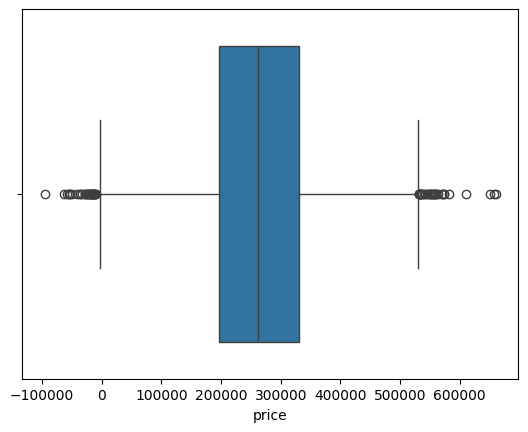

In [5]:
sns.boxplot(x=df['price'])

## EDA Findings
1. How many rows and columns?
   - 10,000 rows
   - 5 columns
3. Which columns have missing data and how much?
   - No missing values
7. Which features appear most correlate with the target?
   - square_feets -> positive
   - distance_to_city(km) -> negative
11. Which columns are you going to DROP and WHY?
    - No features were dropped 

In [30]:
import pandas as pd
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, cross_val_score,KFold
from sklearn.preprocessing import  StandardScaler
from sklearn.linear_model  import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score,mean_absolute_error

In [6]:
# 1. select and clean columns
df_clean = df.copy()

In [7]:
df_clean.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 5 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   square_feet           10000 non-null  float64
 1   num_rooms             10000 non-null  int64  
 2   age                   10000 non-null  int64  
 3   distance_to_city(km)  10000 non-null  float64
 4   price                 10000 non-null  float64
dtypes: float64(3), int64(2)
memory usage: 390.8 KB


In [8]:
# Separating features from target
TARGET = "price"

X = df_clean.drop(columns=TARGET)
y = df_clean[TARGET]

In [9]:
X.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 4 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   square_feet           10000 non-null  float64
 1   num_rooms             10000 non-null  int64  
 2   age                   10000 non-null  int64  
 3   distance_to_city(km)  10000 non-null  float64
dtypes: float64(2), int64(2)
memory usage: 312.6 KB


In [10]:
y.info()

<class 'pandas.Series'>
RangeIndex: 10000 entries, 0 to 9999
Series name: price
Non-Null Count  Dtype  
--------------  -----  
10000 non-null  float64
dtypes: float64(1)
memory usage: 78.3 KB


In [40]:
print(f"Features remaining: {list[X.columns]}")
print(f"\nShape: {X.shape}")
print(f"\nThe Target : {TARGET}")

Features remaining: list[Index(['square_feet', 'num_rooms', 'age', 'distance_to_city(km)'], dtype='str')]

Shape: (10000, 4)

The Target : price


In [33]:
# splitting the data into train and test 
X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y, 
                                                    test_size=0.2,
                                                    random_state=42,
                                                   )
print(f"Train: {X_train.shape} | Test: {X_test.shape}")

Train: (8000, 4) | Test: (2000, 4)


In [13]:
# Building the pipeline
pipeline = Pipeline([
    ('scaler',StandardScaler()),
    ('model',LinearRegression())
])

In [14]:
# train model
pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None


In [15]:
y_pred = pipeline.predict(X_test)

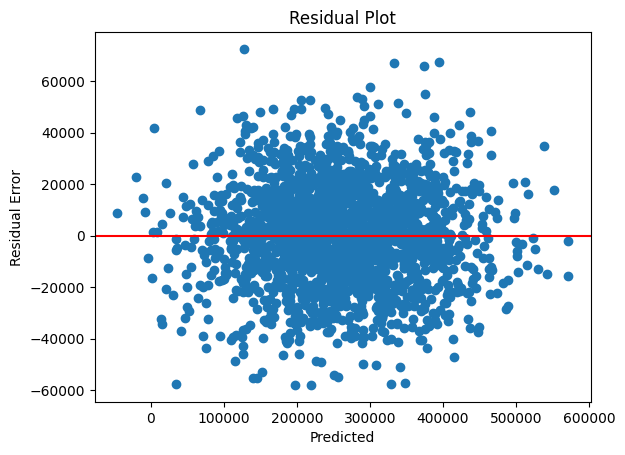

In [21]:
# plot residuals
residuals = y_test - y_pred

plt.scatter(y_pred, residuals)
plt.axhline(y=0, color='red')
plt.xlabel("Predicted")
plt.ylabel("Residual Error")
plt.title("Residual Plot")
plt.show()

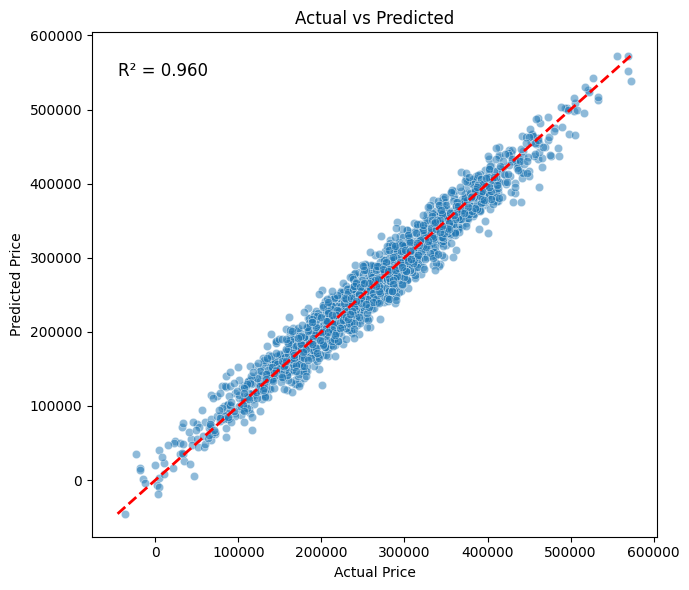

In [36]:
#  ploting actual vs predicted

y_test = np.array(y_test).ravel()
y_pred = np.array(y_pred).ravel()

plt.figure(figsize=(7,6))

sns.scatterplot(x=y_test, y=y_pred, alpha=0.5)

min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())

plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2)

r2 = r2_score(y_test, y_pred)

plt.text(
    min_val,
    max_val * 0.95,
    f"R² = {r2:.3f}",
    fontsize=12
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted")

plt.tight_layout()
plt.show()

### Evaluation and Cross Validation

In [35]:
# basic metrics

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("TEST SET EVALUATION")
print("-" * 30)
print(f"MAE  : {mae:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R2   : {r2:.4f}")

# cross validation

kf = KFold(n_splits=5, shuffle=True, random_state=42)

cv_r2 = cross_val_score(pipeline, X, y, cv=kf, scoring="r2")

cv_rmse = -cross_val_score(pipeline, X, y, cv=kf, scoring="neg_root_mean_squared_error")

print("\nCROSS VALIDATION")
print("-" * 30)
print(f"R2 scores per fold : {cv_r2}")
print(f"Mean R2            : {cv_r2.mean():.4f}")
print(f"Std R2             : {cv_r2.std():.4f}")

print(f"\nRMSE per fold      : {cv_rmse}")
print(f"Mean RMSE          : {cv_rmse.mean():.4f}")
print(f"Std RMSE           : {cv_rmse.std():.4f}")

TEST SET EVALUATION
------------------------------
MAE  : 15596.1205
RMSE : 19658.1743
R2   : 0.9601

CROSS VALIDATION
------------------------------
R2 scores per fold : [0.9600637  0.95934225 0.95711428 0.95549119 0.95952791]
Mean R2            : 0.9583
Std R2             : 0.0017

RMSE per fold      : [19658.17431656 19840.14860361 20300.30632762 20710.32328743
 19848.55520991]
Mean RMSE          : 20071.5015
Std RMSE           : 383.2789
